# 03a — Lexical linker `fuzzy_threshold` tuning

Sweep `LexicalLinker.fuzzy_threshold` on a **1000-example seeded subset of Spider train** scored against **sqlglot-derived Tier-2 gold**. Spider dev is never touched here.

Selection rule: argmax macro table-F1 (column F1 as tie-breaker). Tables are the upstream signal Method G builds on, so they drive the choice.

Outputs:
1. Sweep DataFrame printed below.
2. F1 vs threshold plot for tables and columns.
3. Chosen value written into `config.yaml` at `linkers.lexical.fuzzy_threshold`.

This notebook is transient — production logic lives in `src/schema_linking/utils/tuning.py`.

In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import yaml

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'src'))

from schema_linking.data_loader import load_spider_questions
from schema_linking.gold_link_extractor import extract_tier2_all
from schema_linking.schema_parser import load_schemas
from schema_linking.utils.tuning import tune_fuzzy_threshold

SEED = 42
SUBSET_SIZE = 1000

In [2]:
schemas = load_schemas()
train_all = load_spider_questions('train')
rng = random.Random(SEED)
subset = rng.sample(list(train_all), SUBSET_SIZE)
print(f'schemas: {len(schemas)} dbs, train: {len(train_all)} examples, subset: {len(subset)}')

schemas: 166 dbs, train: 7000 examples, subset: 1000


In [3]:
gold_links = extract_tier2_all(subset, schemas)
gold = {
    qid: {
        'db_id': gl.db_id,
        'tables': list(gl.tables),
        'columns': [list(c) for c in gl.columns],
    }
    for qid, gl in gold_links.items()
}
subset_with_gold = [ex for ex in subset if ex.question_id in gold]
print(f'Tier-2 gold extracted for {len(gold)}/{len(subset)} examples')

column 'Le Pop' unresolvable in db 'music_2' (qid 5238) — skipping
column 'Dayana Robel' unresolvable in db 'insurance_fnol' (qid 912) — skipping
column '%Alex%' unresolvable in db 'customers_and_addresses' (qid 6074) — skipping
column 'Japan' unresolvable in db 'film_rank' (qid 4139) — skipping
column 'A4' unresolvable in db 'store_product' (qid 4931) — skipping
column 'PUR' unresolvable in db 'tracking_share_transactions' (qid 5865) — skipping
column 'Janessa' unresolvable in db 'driving_school' (qid 6630) — skipping
column 'Sawayn' unresolvable in db 'driving_school' (qid 6630) — skipping
column 'Rachel Elnaugh' unresolvable in db 'entrepreneur' (qid 2276) — skipping
column 'Fanny' unresolvable in db 'behavior_monitoring' (qid 3112) — skipping
column 'food' unresolvable in db 'tracking_orders' (qid 6942) — skipping
column 'Collectible card game' unresolvable in db 'game_1' (qid 5977) — skipping
column 'Aerosmith' unresolvable in db 'store_1' (qid 569) — skipping
column 'Colorado' un

Tier-2 gold extracted for 1000/1000 examples


In [4]:
best, sweep = tune_fuzzy_threshold(
    examples=subset_with_gold,
    gold=gold,
    schemas=schemas,
)
print(f'CHOSEN fuzzy_threshold: {best}')
sweep

CHOSEN fuzzy_threshold: 70


,fuzzy_threshold,table_precision,table_recall,table_f1,column_precision,column_recall,column_f1
0,70,0.843433,0.794883,0.751421,0.454631,0.747667,0.486145
1,75,0.862583,0.765183,0.747340,0.493706,0.713722,0.496692
2,80,0.883833,0.738767,0.738660,0.574134,0.647178,0.504773
3,85,0.892667,0.712600,0.721412,0.716222,0.542716,0.487796
4,90,0.908417,0.656983,0.673819,0.765420,0.512320,0.485155
5,95,0.918083,0.630983,0.652629,0.788945,0.487942,0.477181


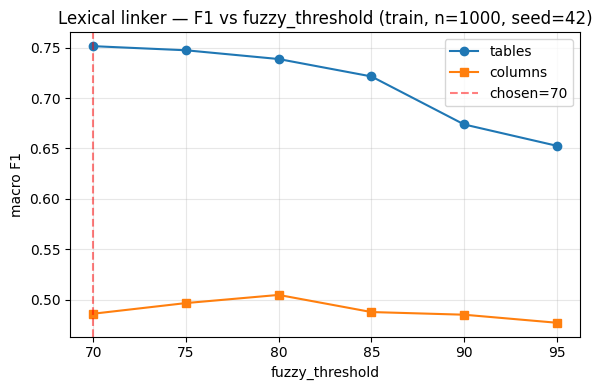

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sweep['fuzzy_threshold'], sweep['table_f1'], marker='o', label='tables')
ax.plot(sweep['fuzzy_threshold'], sweep['column_f1'], marker='s', label='columns')
ax.axvline(best, color='red', linestyle='--', alpha=0.5, label=f'chosen={best}')
ax.set_xlabel('fuzzy_threshold')
ax.set_ylabel('macro F1')
ax.set_title('Lexical linker — F1 vs fuzzy_threshold (train, n=1000, seed=42)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
cfg_path = REPO_ROOT / 'config.yaml'
with cfg_path.open(encoding='utf-8') as f:
    cfg_raw = yaml.safe_load(f) or {}
cfg_raw.setdefault('linkers', {}).setdefault('lexical', {})['fuzzy_threshold'] = int(best)
with cfg_path.open('w', encoding='utf-8') as f:
    yaml.safe_dump(cfg_raw, f, sort_keys=False)
print(f'wrote linkers.lexical.fuzzy_threshold = {best} to {cfg_path}')

wrote linkers.lexical.fuzzy_threshold = 70 to /Users/mac/Documents/Masters BHT 2023-2025/Semester 6 2026 april-sep/code/config.yaml
